In [0]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 24.9 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 MB 123.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install scikit-optimize

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql.window import Window
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.utils import check_array
from sklearn.utils import check_consistent_length
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler,Normalizer

pd.set_option('display.max_rows', 520)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [0]:

def convertir_numeros(df,columns):
    for col in columns:
        df[col] = pd.to_numeric(df[col])
    return df

def convertir_fechas(df,columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col])
    return df

def limpiar_espacios(df):
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip()
    return df

def homologar_id(id_raw):
    id_str = str(id_raw).lstrip("0")
    return id_str.zfill(10)

def tabla_frecuencias_estadistica(serie):
    serie = serie.dropna()
    n = len(serie)
    k = int(np.ceil(1 + 3.322 * math.log10(n)))  # número de intervalos
    rango = serie.max() - serie.min()
    amplitud = np.ceil(rango / k)
    limites = np.arange(serie.min(), serie.max() + amplitud, amplitud)
    intervalos = pd.cut(serie, bins=limites, right=True, include_lowest=True)
    tabla = intervalos.value_counts(sort=False).reset_index()
    tabla.columns = ['Intervalo', 'Frecuencia']
    tabla['Frecuencia Relativa'] = (tabla['Frecuencia']/n*100).round(2).astype(str) + ' %'
    tabla['Frecuencia Acumulada'] = tabla['Frecuencia'].cumsum()
    tabla['Frecuencia Relativa Acum.'] = ((tabla['Frecuencia']/n*100).cumsum()).round(2).astype(str) + ' %'
    return tabla


def numeric_eda(data, numerical_list):
    len_list = []
    null_list = []
    null_per_list = []
    mean_list = []
    std_list = []
    min_list = []
    per_1_list = []
    per_5_list = []
    per_25_list = []
    median_list = []
    per_75_list = []
    per_95_list = []
    per_99_list = []
    max_list = []
    
    data = data[numerical_list]

    for i in data.columns:
        len_v = len(data)
        len_list.append(len_v)
        null_v = data[i].isnull().sum()
        null_list.append(null_v)
        null_per_v = null_v/len_v
        null_per_list.append(null_per_v)
        mean_v = np.mean(data[i])
        mean_list.append(mean_v)
        std_v = np.std(data[i])
        std_list.append(std_v)
        min_v = np.min(data[i])
        min_list.append(min_v)
        per_1_v = np.percentile(data[i].dropna(), 1)
        per_1_list.append(per_1_v)
        per_5_v = np.percentile(data[i].dropna(), 5)
        per_5_list.append(per_5_v)
        per_25_v = np.percentile(data[i].dropna(), 25)
        per_25_list.append(per_25_v)
        median_v = np.median(data[i].dropna())
        median_list.append(median_v)
        per_75_v = np.percentile(data[i].dropna(), 75)
        per_75_list.append(per_75_v)
        per_95_v = np.percentile(data[i].dropna(), 95)
        per_95_list.append(per_95_v)
        per_99_v = np.percentile(data[i].dropna(), 99)
        per_99_list.append(per_99_v)
        max_v = np.max(data[i])
        max_list.append(max_v)

    numeric_df = pd.DataFrame({"variable": data.columns,
                               "num_datos": len_list,
                               "num_null": null_list,
                               "per_null": null_per_list,
                               "mean": mean_list,
                               "std": std_list,
                               "min": min_list,
                               "per_1": per_1_list,
                               "per_5": per_5_list,
                               "per_25": per_25_list,
                               "median": median_list,
                               "per_75": per_75_list,
                               "per_95": per_95_list,
                               "per_99": per_99_list,
                               "max": max_list
                               })

    return numeric_df


def category_eda(data, categorical_vr):
    category_list = []
    num_category_list = []
    mode_list = []
    mode_count_list = []
    len_list = []
    count_list = []
    mode_per_list = []
    mode_per_sin_null_list = []
    for i in categorical_vr:
        category_v = data[i].unique()
        category_list.append(category_v)
        num_category_v = len(category_v)
        num_category_list.append(num_category_v)
        mode_v = data[i].mode()[0]
        mode_list.append(mode_v)
        mode_count_v = len(data[i][data[i] == mode_v])
        mode_count_list.append(mode_count_v)
        len_v = len(data)
        len_list.append(len_v)
        count_v = data[i].count()
        count_list.append(count_v)
        mode_per_v = mode_count_v/len_v
        mode_per_list.append(mode_per_v)
        mode_per_sin_null_v = mode_count_v/count_v
        mode_per_sin_null_list.append(mode_per_sin_null_v)

    category_df = pd.DataFrame({"variable": categorical_vr,
                                "num_category": num_category_list,
                                "mode": mode_list,
                                "mode_count": mode_count_list,
                                "num_datos": len_list,
                                "count_datos": count_list,
                                "mode_per_total": mode_per_list,
                                "mode_per_sin_null": mode_per_sin_null_list,
                                "category": category_list})
    return category_df


def plot_boxplots(df, y, x_vars,hline=0,nrows=1, ncols=1, figsize=(12, 6)):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()
    for i, x in enumerate(x_vars):
        if i < len(axes):  
            sns.boxplot(x=x, y=y, data=df, ax=axes[i])
            plt.setp(axes[i].artists, alpha=.5, linewidth=2, edgecolor="k")
            axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
            axes[i].axhline(hline, color='red', linestyle='--')
            axes[i].set_title(f'Boxplot for {x}')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


def step_log(data,vars_name):
    def trans_log(x):
        if abs(x)>=1:
            return math.copysign(1, x)*np.log(abs(x))
        else:
            return 0
    for i in vars_name:
        data[i] = data[i].map(lambda x: trans_log(x))
    return data


def iv_df_opt(data, cat_list, num_list, target):
    y = data[target]
    iv_var_cat = []
    iv_var_num = []

    for i in cat_list:
        x = data[i].values
        optb = OptimalBinning(name=i, dtype="categorical", solver="cp", max_n_bins=8)
        optb.fit(x, y)
        binning_table = optb.binning_table.build()
        iv = binning_table.IV.loc["Totals"]
        iv_var_cat.append(iv)

    for i in num_list:
        x = data[i].values
        optb = OptimalBinning(name=i, dtype="numerical", solver="cp", max_n_bins=8)
        optb.fit(x, y)
        binning_table = optb.binning_table.build()
        iv = binning_table.IV.loc["Totals"]
        iv_var_num.append(iv)
    df = pd.DataFrame()
    df["variable"] = cat_list + num_list
    df["iv"] = iv_var_cat + iv_var_num
    df = df.sort_values(by="iv", ascending=False).reset_index(drop=True)
    return df


def calc_vif(X):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)


def _check_arrays(y, y_pred):
    y = check_array(y, ensure_2d=False, force_all_finite=True)
    y_pred = check_array(y_pred, ensure_2d=False, force_all_finite=True)
    check_consistent_length(y, y_pred)
    return y, y_pred


def corte_optimo(y,y_pred):
    y, y_pred = _check_arrays(y, y_pred)

    n_samples = y.shape[0]
    n_event = np.sum(y)
    n_nonevent = n_samples - n_event

    idx = y_pred.argsort()
    yy = y[idx]
    pp = y_pred[idx]

    cum_event = np.cumsum(yy)
    cum_population = np.arange(0, n_samples)
    cum_nonevent = cum_population - cum_event

    p_event = cum_event / n_event
    p_nonevent = cum_nonevent / n_nonevent

    p_diff = p_nonevent - p_event
    ks_score = np.max(p_diff)
    ks_max_idx = np.argmax(p_diff)
    return pp[ks_max_idx]


def ks_metric(data, probability, real):
    data = data.sort_values(by=probability, ascending=True).reset_index(drop = True) 
    data["Index"] = data.index 
    data['Decile'] = pd.qcut(data["Index"], 10) 
    grouped = data.groupby('Decile', as_index = False) 
    cumsum = 0
    ks_list = []
    list_cumPercentage = []
    percentage = (grouped.count()[real]-grouped.sum()[real])/((grouped.count()[real]-grouped.sum()[real]).sum()) 
    for i in percentage:
        cumsum = cumsum+i
        list_cumPercentage.append(cumsum)
    cumsum_no_event = pd.Series(list_cumPercentage) 
    cumsum_event = (grouped.sum()[real]/grouped.sum()[real].sum()).cumsum()
    ks = cumsum_no_event-cumsum_event
    return max(ks)


def model_metrics(data):
    prediction = data['Adjusted Prediction']
    probability = data['Probability'] 
    y_true = data['True Dependent Variable']
    print("Accuracy:",accuracy_score(y_true, prediction))
    print("Balanced Accuracy:",balanced_accuracy_score(y_true, prediction))
    print('ks:',ks_metric(data,'Probability','True Dependent Variable'))
    print("ROC AUC:", roc_auc_score(y_true,probability))
    print("Gini:", (2*roc_auc_score(y_true, probability) -1))
    tp, fn, fp, tn = confusion_matrix(y_true,prediction).ravel()
    print('Negative Predicted value: ',(tn/(tn+fn)) )
    print('Positive Predicted value: ',(tp/(tp+fp)))
    print('Sensitivity: ',(tp/(tp+fn)) )
    print('Specificity: ',(tn/(fp+tn)) )
    print('tp, fn, fp, tn=: ',[tp, fn, fp, tn])
    print("Confusion Matrix:")
    print(confusion_matrix(y_true,prediction))
    print(classification_report(y_true,prediction))    

def adjusted_prediction(y_true, probability, low_cut_probability, high_cut_probability):
    df = pd.DataFrame({'Probability':probability,'True Dependent Variable': y_true})
    df['Adjusted Prediction'] = np.where(df['Probability']<=low_cut_probability,0,
                                        np.where(df['Probability']>=high_cut_probability,1,2))
    return df[df['Adjusted Prediction']!=2]

def preparar_datos(df):
    df = df.copy()
    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        df[col] = df[col].astype("category")
    return df

def preprocesar(df):
    df = df.copy()
    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        df[col] = df[col].astype("category")
    num_cols = df.select_dtypes(include=["number"]).columns
    scaler = MinMaxScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])
    return df, scaler

In [0]:
df_trx_cl = spark.read.parquet("/Volumes/workspace/default/data_upload/dataset/")

## Análisis inicial

In [0]:
df_trx_cl.limit(10).display()

cliente_id,pais_cd,region_comercial_txt,agencia_id,ruta_id,tipo_cliente_cd,madurez_digital_cd,estrellas_txt,frecuencia_visitas_cd,fecha_pedido_dt,canal_pedido_cd,facturacion_usd_val,materiales_distintos_val,cajas_fisicas
C089085,SV,ORIENTE,SV-ORI-A002,SV-ORI-A002-R003,TIENDA,BAJA,1,LMV,2023-05-17T00:00:00.000Z,VENDEDOR,161.55,4,3.21
C073952,GT,NORTE,GT-NOR-A010,GT-NOR-A010-R009,TIENDA,BAJA,1,LMI,2023-10-07T00:00:00.000Z,VENDEDOR,137.36,2,7.42
C101443,GT,METROPOLITANA,GT-MET-A002,GT-MET-A002-R010,TIENDA,ALTA,1,LMV,2023-01-05T00:00:00.000Z,DIGITAL,80.77,8,13.53
C055939,PE,SELVA,PE-SEL-A002,PE-SEL-A002-R013,MINIMARKET,BAJA,1,LMV,2024-01-13T00:00:00.000Z,DIGITAL,92.68,2,16.67
C088826,EC,SIERRA,EC-SIE-A002,EC-SIE-A002-R005,TIENDA,MEDIA,2,L,2023-10-01T00:00:00.000Z,DIGITAL,125.18,3,16.37
C097102,SV,OCCIDENTE,SV-OCC-A008,SV-OCC-A008-R010,TIENDA,BAJA,2,LM,2023-08-24T00:00:00.000Z,DIGITAL,26.61,10,11.58
C127527,SV,OCCIDENTE,SV-OCC-A010,SV-OCC-A010-R015,MINIMARKET,MEDIA,2,L,2023-01-26T00:00:00.000Z,TELEFONO,155.09,7,21.38
C011635,SV,OCCIDENTE,SV-OCC-A005,SV-OCC-A005-R016,TIENDA,ALTA,3,L,2024-01-31T00:00:00.000Z,VENDEDOR,111.17,9,11.62
C009248,EC,SIERRA,EC-SIE-A005,EC-SIE-A005-R017,MAYORISTA,MEDIA,1,LM,2023-10-13T00:00:00.000Z,TELEFONO,19.67,14,21.99
C012845,PE,SUR,PE-SUR-A001,PE-SUR-A001-R006,TIENDA,MEDIA,1,LM,2023-03-26T00:00:00.000Z,TELEFONO,171.58,9,8.89


In [0]:
df_trx_cl.count()

1250000

Tenemos 14 columnas y 1250000 filas en el dataset

In [0]:
for col in df_trx_cl.columns:
    print(col.ljust(20), df_trx_cl.filter(df_trx_cl[col].isNull()).count())

cliente_id           0
pais_cd              0
region_comercial_txt 0
agencia_id           0
ruta_id              0
tipo_cliente_cd      0
madurez_digital_cd   0
estrellas_txt        0
frecuencia_visitas_cd 0
fecha_pedido_dt      0
canal_pedido_cd      0
facturacion_usd_val  0
materiales_distintos_val 0
cajas_fisicas        0


No existe columnas con valores faltantes

### Variables númericas

In [0]:
df_trx_cl.select('facturacion_usd_val','cajas_fisicas')\
    .summary('mean', 'min', '10%', '25%', '50%', '75%', '90%', 'max').display()

summary,facturacion_usd_val,cajas_fisicas
mean,120.32333305599997,12.028039223999999
min,0.0,0.0
10%,55.98,5.6
25%,86.36,8.63
50%,120.08,12.0
75%,153.76,15.37
90%,184.04,18.4
max,366.38,38.15


Las variables numéricas siguen una distribución normal, se ve gráficamente y porque la media y la mediana casi coinciden eso da pistas de que siguen una distribución normal. 

### Análisis de la evolución de pedidos

In [0]:
df_trx_cl.agg(F.min("fecha_pedido_dt"),F.max("fecha_pedido_dt")).display()

min(fecha_pedido_dt),max(fecha_pedido_dt)
2023-01-01T00:00:00.000Z,2024-08-23T00:00:00.000Z


In [0]:
df_mensual = (
    df_trx_cl
    .withColumn("mes", F.date_trunc("month", F.col("fecha_pedido_dt")))
    .groupBy("mes", "canal_pedido_cd")
    .agg(F.countDistinct("cliente_id").alias("clientes_unicos"))
    .orderBy("mes", "canal_pedido_cd")
)

pdf = df_mensual.toPandas()
pdf["mes"] = pd.to_datetime(pdf["mes"])

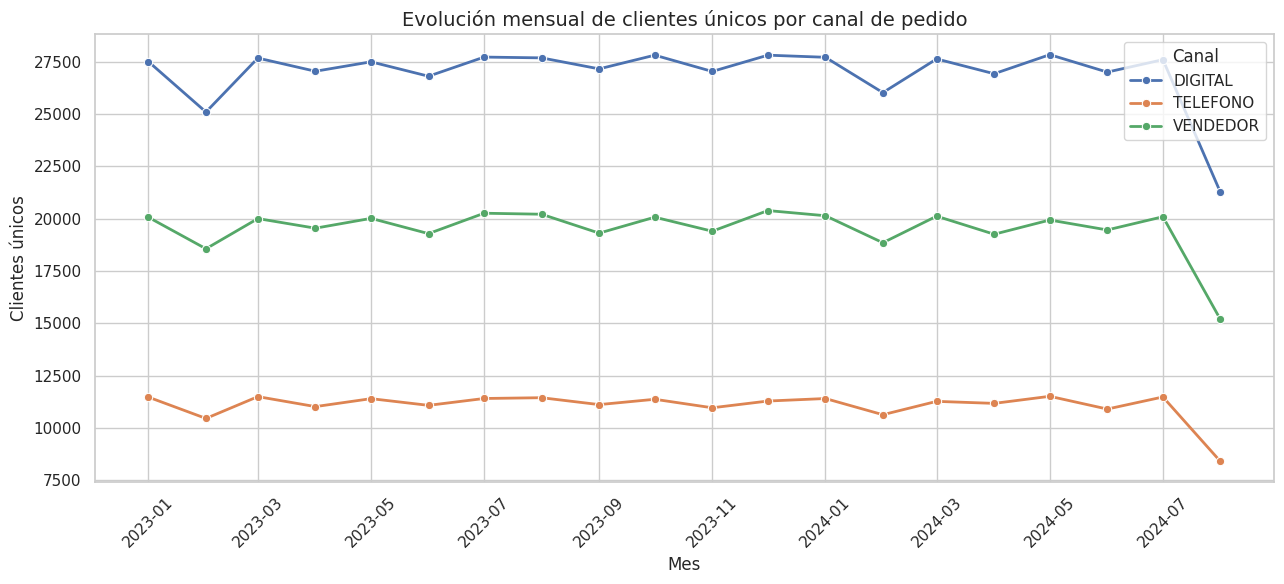

In [0]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 6))

ax = sns.lineplot(
    data=pdf,
    x="mes",
    y="clientes_unicos",
    hue="canal_pedido_cd",
    marker="o",
    linewidth=2,
)

ax.set_title("Evolución mensual de clientes únicos por canal de pedido", fontsize=14)
ax.set_xlabel("Mes")
ax.set_ylabel("Clientes únicos")
ax.legend(title="Canal")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Generamos la master data table con la target

Primero armo un plan para visualizar lo que quiero predecir y las features que me ayudarán. 

In [0]:
# --- 1. Marcar el último pedido de cada cliente (= target) ---
w_desc = Window.partitionBy("cliente_id").orderBy(F.col("fecha_pedido_dt").desc())
df = df_trx_cl.withColumn("rn_desc", F.row_number().over(w_desc))

# Pedido objetivo: el más reciente. 
target = (
    df.filter(F.col("rn_desc") == 1)
      .withColumn("is_digital", (F.col("canal_pedido_cd") == "DIGITAL").cast("int"))
      .select(
          "cliente_id",
          F.col("fecha_pedido_dt").alias("fecha_target"),
          "is_digital",
          "pais_cd", "region_comercial_txt", "tipo_cliente_cd",
          "madurez_digital_cd", "estrellas_txt", "frecuencia_visitas_cd",
      )
)


In [0]:
# --- 2. Historial: todos los pedidos ANTERIORES al objetivo ---
hist = (
    df.filter(F.col("rn_desc") > 1)
      .withColumn("is_digital",  (F.col("canal_pedido_cd") == "DIGITAL").cast("int"))
      .withColumn("is_vendedor", (F.col("canal_pedido_cd") == "VENDEDOR").cast("int"))
      .withColumn("is_telefono", (F.col("canal_pedido_cd") == "TELEFONO").cast("int"))
)


In [0]:
# --- 3. Features agregadas del historial ---
feats = hist.groupBy("cliente_id").agg(
    F.count("*").alias("n_pedidos_prev"),
    F.avg("is_digital").alias("pct_digital_prev"),
    F.avg("is_vendedor").alias("pct_vendedor_prev"),
    F.avg("is_telefono").alias("pct_telefono_prev"),
    F.sum("is_digital").alias("n_digital_prev"),
    F.max("is_digital").alias("ever_digital_prev"),
    F.avg("facturacion_usd_val").alias("fact_avg_prev"),
    F.sum("facturacion_usd_val").alias("fact_total_prev"),
    F.avg("materiales_distintos_val").alias("materiales_avg_prev"),
    F.avg("cajas_fisicas").alias("cajas_avg_prev"),
    F.min("fecha_pedido_dt").alias("fecha_primer_pedido"),
    F.max("fecha_pedido_dt").alias("fecha_ultimo_prev"),
)

In [0]:
# Canal del pedido inmediatamente anterior al objetivo (rn_desc == 2)
prev_canal = (
    df.filter(F.col("rn_desc") == 2)
      .select("cliente_id", F.col("canal_pedido_cd").alias("canal_pedido_prev"))
)

In [0]:
# --- 4. Ensamblar el dataset a nivel de cliente ---
dataset = (
    target
    # inner join => descarta clientes con un solo pedido (sin historial para features)
    .join(feats, "cliente_id", "inner")
    .join(prev_canal, "cliente_id", "left")
    .withColumn("dias_desde_ultimo_pedido",
                F.datediff("fecha_target", "fecha_ultimo_prev"))
    .withColumn("antiguedad_dias",
                F.datediff("fecha_target", "fecha_primer_pedido"))
    .withColumn("freq_pedidos_mes",
                F.col("n_pedidos_prev") / (F.greatest("antiguedad_dias", F.lit(1)) / 30.0))
    .drop("fecha_primer_pedido", "fecha_ultimo_prev")
)

In [0]:
dataset.limit(10).display()

cliente_id,fecha_target,is_digital,pais_cd,region_comercial_txt,tipo_cliente_cd,madurez_digital_cd,estrellas_txt,frecuencia_visitas_cd,n_pedidos_prev,pct_digital_prev,pct_vendedor_prev,pct_telefono_prev,n_digital_prev,ever_digital_prev,fact_avg_prev,fact_total_prev,materiales_avg_prev,cajas_avg_prev,canal_pedido_prev,dias_desde_ultimo_pedido,antiguedad_dias,freq_pedidos_mes
C000004,2024-07-17T00:00:00.000Z,0,PE,SUR,TIENDA,BAJA,1,LM,8,0.75,0.25,0.0,6,1,126.62000000000002,1012.9600000000002,8.25,13.3475,DIGITAL,46,544,0.4411764705882353
C000007,2024-08-01T00:00:00.000Z,0,SV,OCCIDENTE,TIENDA,BAJA,2,LMI,11,0.2727272727272727,0.45454545454545453,0.2727272727272727,3,1,119.23818181818183,1311.6200000000001,6.818181818181818,10.671818181818182,VENDEDOR,9,382,0.8638743455497383
C000009,2024-07-06T00:00:00.000Z,1,SV,OCCIDENTE,MINIMARKET,MEDIA,2,LM,11,0.45454545454545453,0.36363636363636365,0.18181818181818182,5,1,105.35636363636364,1158.92,6.7272727272727275,11.336363636363636,TELEFONO,31,523,0.6309751434034416
C000012,2023-11-27T00:00:00.000Z,0,EC,COSTA,MINIMARKET,BAJA,1,LMV,5,0.0,0.4,0.6,0,0,105.27799999999999,526.39,6.2,10.808,TELEFONO,5,237,0.6329113924050632
C000023,2024-08-16T00:00:00.000Z,1,PE,CENTRO,MINIMARKET,BAJA,1,LM,18,0.4444444444444444,0.16666666666666666,0.3888888888888889,8,1,133.14055555555555,2396.5299999999997,6.833333333333333,12.124444444444443,DIGITAL,42,533,1.0131332082551596
C000037,2024-08-23T00:00:00.000Z,0,SV,OCCIDENTE,MAYORISTA,BAJA,2,LM,9,0.4444444444444444,0.4444444444444444,0.1111111111111111,4,1,102.16666666666667,919.5,10.222222222222221,12.692222222222222,VENDEDOR,11,442,0.6108597285067874
C000051,2024-08-01T00:00:00.000Z,1,GT,NORTE,TIENDA,BAJA,1,LMI,5,0.4,0.4,0.2,2,1,104.904,524.52,10.2,15.491999999999999,DIGITAL,100,368,0.4076086956521739
C000056,2024-05-08T00:00:00.000Z,0,SV,ORIENTE,TIENDA,BAJA,2,LMI,6,0.16666666666666666,0.6666666666666666,0.16666666666666666,1,1,94.08,564.48,7.333333333333333,14.858333333333333,VENDEDOR,69,451,0.3991130820399113
C000057,2024-06-21T00:00:00.000Z,0,SV,ORIENTE,MINIMARKET,BAJA,1,LMV,9,0.5555555555555556,0.2222222222222222,0.2222222222222222,5,1,119.4511111111111,1075.06,8.333333333333334,9.605555555555556,TELEFONO,14,345,0.782608695652174
C000064,2024-06-23T00:00:00.000Z,0,GT,METROPOLITANA,MINIMARKET,MEDIA,1,LM,9,0.4444444444444444,0.5555555555555556,0.0,4,1,111.55,1003.9499999999999,8.444444444444445,13.965555555555556,DIGITAL,50,441,0.6122448979591837


Validemos unitarias

In [0]:
df_trx_cl.filter("cliente_id=='C000012'").orderBy(F.desc("fecha_pedido_dt")).limit(100).display()

cliente_id,pais_cd,region_comercial_txt,agencia_id,ruta_id,tipo_cliente_cd,madurez_digital_cd,estrellas_txt,frecuencia_visitas_cd,fecha_pedido_dt,canal_pedido_cd,facturacion_usd_val,materiales_distintos_val,cajas_fisicas
C000012,EC,COSTA,EC-COS-A003,EC-COS-A003-R005,MINIMARKET,BAJA,1,LMV,2023-11-27T00:00:00.000Z,TELEFONO,125.48,14,9.13
C000012,EC,COSTA,EC-COS-A003,EC-COS-A003-R005,MINIMARKET,BAJA,1,LMV,2023-11-22T00:00:00.000Z,TELEFONO,88.97,2,8.8
C000012,EC,COSTA,EC-COS-A003,EC-COS-A003-R005,MINIMARKET,BAJA,1,LMV,2023-09-04T00:00:00.000Z,TELEFONO,117.49,11,10.78
C000012,EC,COSTA,EC-COS-A003,EC-COS-A003-R005,MINIMARKET,BAJA,1,LMV,2023-07-24T00:00:00.000Z,TELEFONO,152.75,1,10.05
C000012,EC,COSTA,EC-COS-A003,EC-COS-A003-R005,MINIMARKET,BAJA,1,LMV,2023-05-06T00:00:00.000Z,VENDEDOR,94.3,12,13.26
C000012,EC,COSTA,EC-COS-A003,EC-COS-A003-R005,MINIMARKET,BAJA,1,LMV,2023-04-04T00:00:00.000Z,VENDEDOR,72.88,5,11.15


### Dividimos en train test 

In [0]:
fecha_corte = "2024-08-01"

train = dataset.filter(F.col("fecha_target") <  F.lit(fecha_corte))
test  = dataset.filter(F.col("fecha_target") >= F.lit(fecha_corte))

# --- Conteo de clientes y porcentaje ---
n_train = train.count()
n_test  = test.count()
n_total = n_train + n_test

print(f"Fecha de corte: {fecha_corte}")
print(f"Train: {n_train:,} clientes ({n_train / n_total:.1%})")
print(f"Test:  {n_test:,} clientes ({n_test / n_total:.1%})")
print(f"Total: {n_total:,} clientes")

Fecha de corte: 2024-08-01
Train: 108,682 clientes (72.6%)
Test:  40,973 clientes (27.4%)
Total: 149,655 clientes


Nos quedamos con esta separación de 72% para train y 27% para test

Balance de la target

In [0]:
train.groupBy("is_digital").count().show()

+----------+-----+
|is_digital|count|
+----------+-----+
|         1|52166|
|         0|56516|
+----------+-----+



In [0]:
test.groupBy("is_digital").count().show()

+----------+-----+
|is_digital|count|
+----------+-----+
|         1|19773|
|         0|21200|
+----------+-----+



# Análisis exploratorio de datos

In [0]:
train_df = train.toPandas()
test_df = test.toPandas()

In [0]:
cat_cols = [
    "pais_cd",
    "region_comercial_txt",
    "tipo_cliente_cd",
    "madurez_digital_cd",
    "estrellas_txt",
    "frecuencia_visitas_cd",
    "canal_pedido_prev",
    "ever_digital_prev",
]

num_cols = [
    "n_pedidos_prev",
    "pct_digital_prev",
    "pct_vendedor_prev",
    "pct_telefono_prev",
    "n_digital_prev",
    "fact_avg_prev",
    "fact_total_prev",
    "materiales_avg_prev",
    "cajas_avg_prev",
    "dias_desde_ultimo_pedido",
    "antiguedad_dias",
    "freq_pedidos_mes",
]

target = "is_digital"

In [0]:
numeric_eda(train_df, num_cols)

,variable,num_datos,num_null,per_null,mean,std,min,per_1,per_5,per_25,median,per_75,per_95,per_99,max
0,n_pedidos_prev,108682,0,0.0,7.029517,2.798535,1.000000,1.000000,3.000000,5.000000,7.000000,9.000000,12.000000,14.000000,24.00
1,pct_digital_prev,108682,0,0.0,0.480085,0.247573,0.000000,0.000000,0.000000,0.300000,0.500000,0.666667,0.909091,1.000000,1.00
2,pct_vendedor_prev,108682,0,0.0,0.335431,0.209201,0.000000,0.000000,0.000000,0.200000,0.333333,0.500000,0.666667,1.000000,1.00
3,pct_telefono_prev,108682,0,0.0,0.184484,0.176550,0.000000,0.000000,0.000000,0.000000,0.166667,0.285714,0.500000,0.666667,1.00
4,n_digital_prev,108682,0,0.0,3.371110,2.142305,0.000000,0.000000,0.000000,2.000000,3.000000,5.000000,7.000000,10.000000,19.00
5,fact_avg_prev,108682,0,0.0,120.345511,20.881420,1.615000,69.154050,86.906879,107.288571,120.280000,133.295000,154.086633,172.055457,289.18
6,fact_total_prev,108682,0,0.0,845.910181,361.150623,1.840000,143.218200,300.740000,584.800000,818.350000,1075.337500,1486.350000,1799.465200,2973.05
7,materiales_avg_prev,108682,0,0.0,7.504632,1.701058,1.000000,3.333333,4.750000,6.428571,7.500000,8.600000,10.250000,11.666667,14.00
8,cajas_avg_prev,108682,0,0.0,12.025234,2.086751,0.120000,6.952971,8.688333,10.710994,12.021548,13.324286,15.400000,17.207975,27.87
9,dias_desde_ultimo_pedido,108682,0,0.0,71.758405,70.472191,0.000000,1.000000,4.000000,21.000000,50.000000,100.000000,215.000000,325.000000,568.00


In [0]:
category_eda(train_df, cat_cols)

,variable,num_category,mode,mode_count,num_datos,count_datos,mode_per_total,mode_per_sin_null,category
0,pais_cd,4,PE,27196,108682,108682,0.250235,0.250235,"[PE, SV, EC, GT]"
1,region_comercial_txt,11,OCCIDENTE,24256,108682,108682,0.223183,0.223183,"[SUR, OCCIDENTE, COSTA, ORIENTE, METROPOLITANA..."
2,tipo_cliente_cd,3,TIENDA,65168,108682,108682,0.599621,0.599621,"[TIENDA, MINIMARKET, MAYORISTA]"
3,madurez_digital_cd,3,BAJA,54448,108682,108682,0.500985,0.500985,"[BAJA, MEDIA, ALTA]"
4,estrellas_txt,3,1,47321,108682,108682,0.435408,0.435408,"[1, 2, 3]"
5,frecuencia_visitas_cd,4,LM,27269,108682,108682,0.250906,0.250906,"[LM, LMV, LMI, L]"
6,canal_pedido_prev,3,DIGITAL,52164,108682,108682,0.479969,0.479969,"[DIGITAL, TELEFONO, VENDEDOR]"
7,ever_digital_prev,2,1,102872,108682,108682,0.946541,0.946541,"[1, 0]"


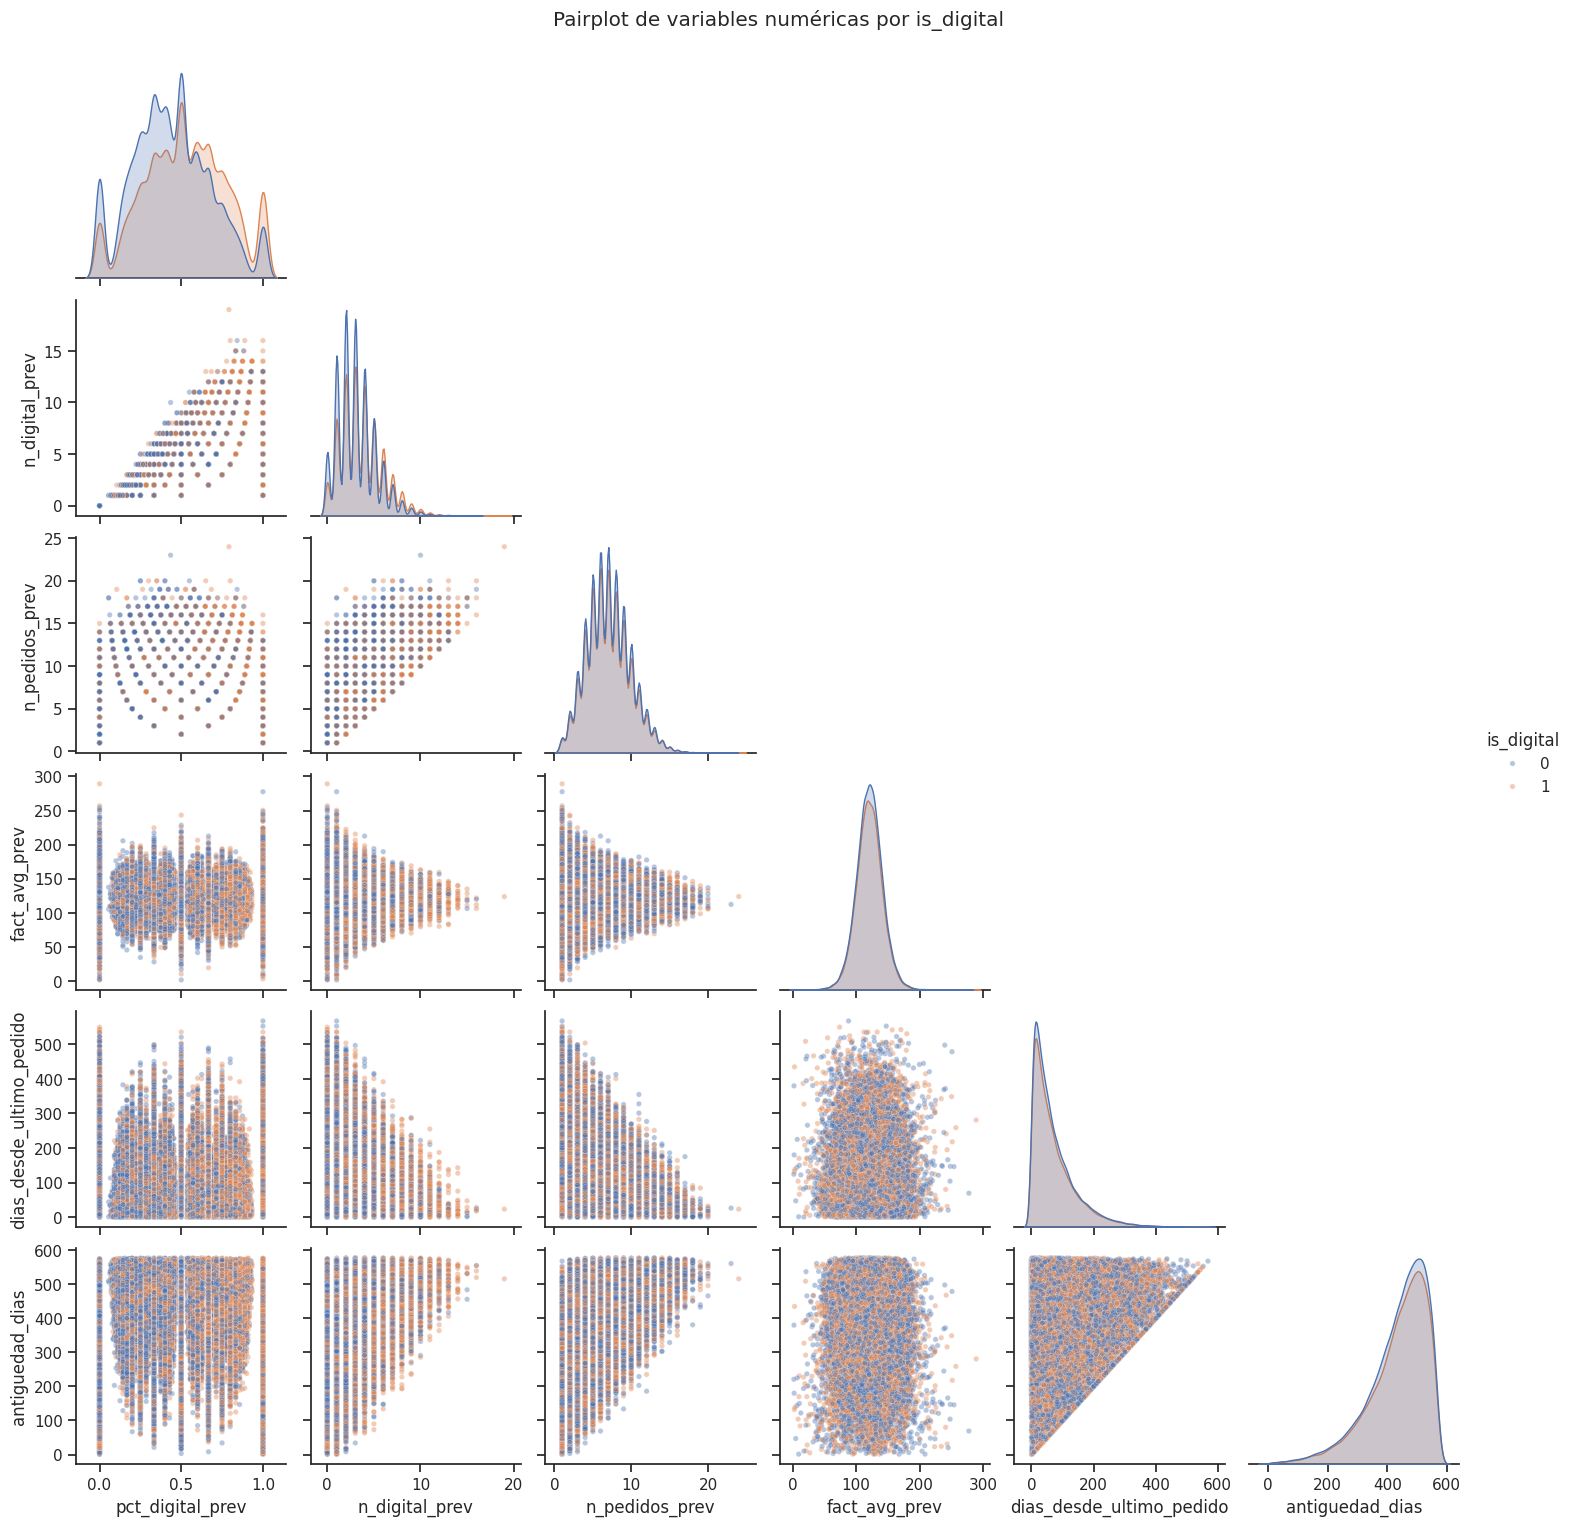

In [0]:
sns.set_theme(style="ticks")

# Opción A: subconjunto de las numéricas más informativas 
num_key = [
    "pct_digital_prev", "n_digital_prev", "n_pedidos_prev",
    "fact_avg_prev", "dias_desde_ultimo_pedido", "antiguedad_dias",
]

sns.pairplot(
    train_df[num_key + [target]],
    hue=target,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    corner=True,         
)
plt.suptitle("Pairplot de variables numéricas por is_digital", y=1.02)
plt.show()

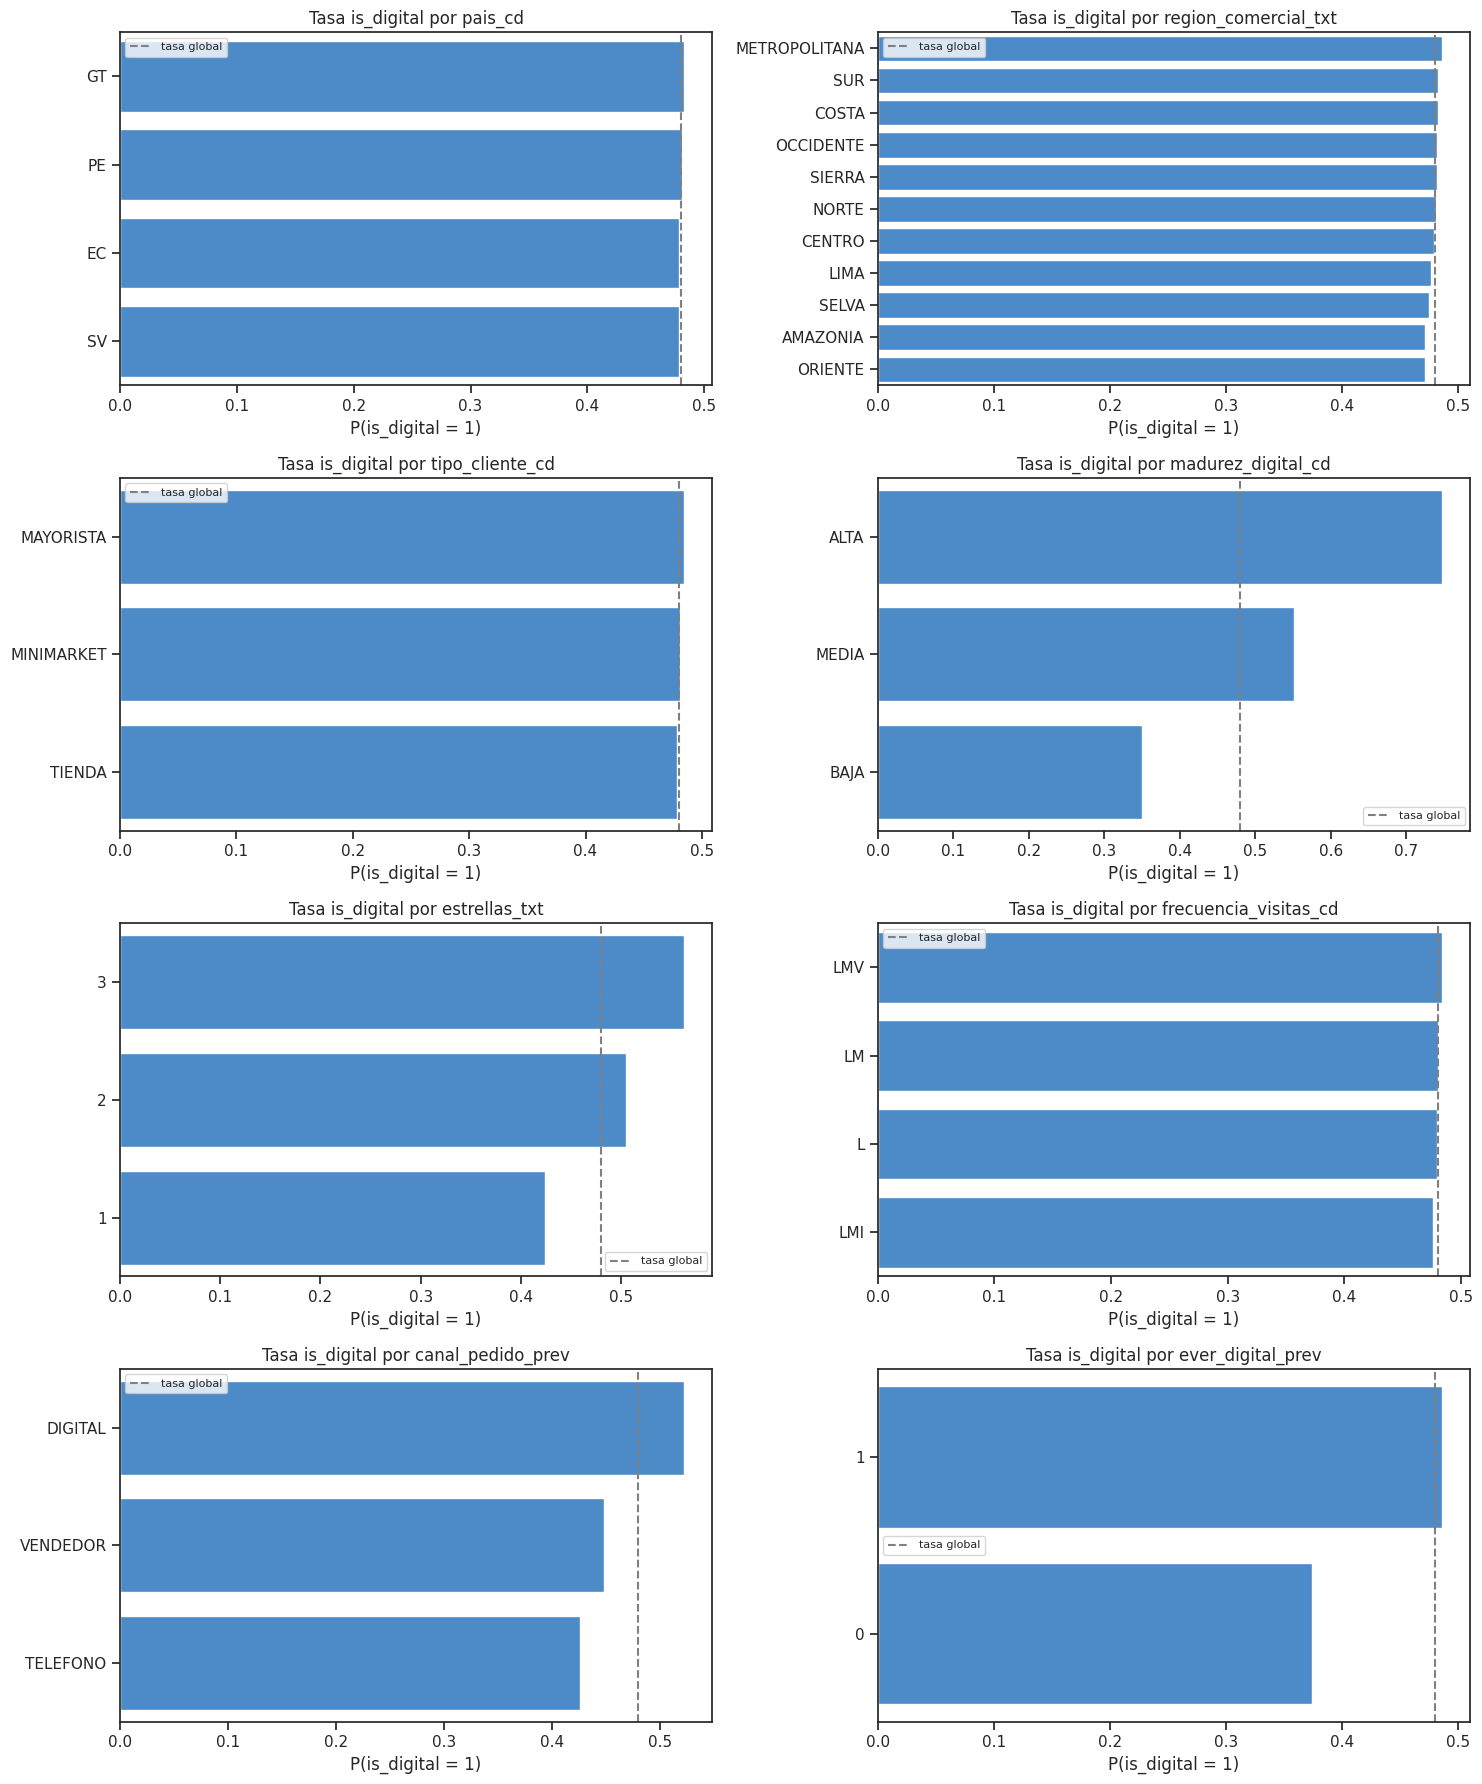

In [0]:
n = len(cat_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    # Tasa de digital por categoría, ordenada
    tasa = (
        train_df.groupby(col)[target]
        .mean()
        .sort_values(ascending=False)
    )
    sns.barplot(x=tasa.values, y=tasa.index.astype(str), ax=ax, color="#378ADD")
    ax.axvline(train_df[target].mean(), ls="--", color="grey",
               label="tasa global")
    ax.set_title(f"Tasa is_digital por {col}")
    ax.set_xlabel("P(is_digital = 1)")
    ax.set_ylabel("")
    ax.legend(fontsize=8)

# Ocultar ejes sobrantes
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Análisis multivariado

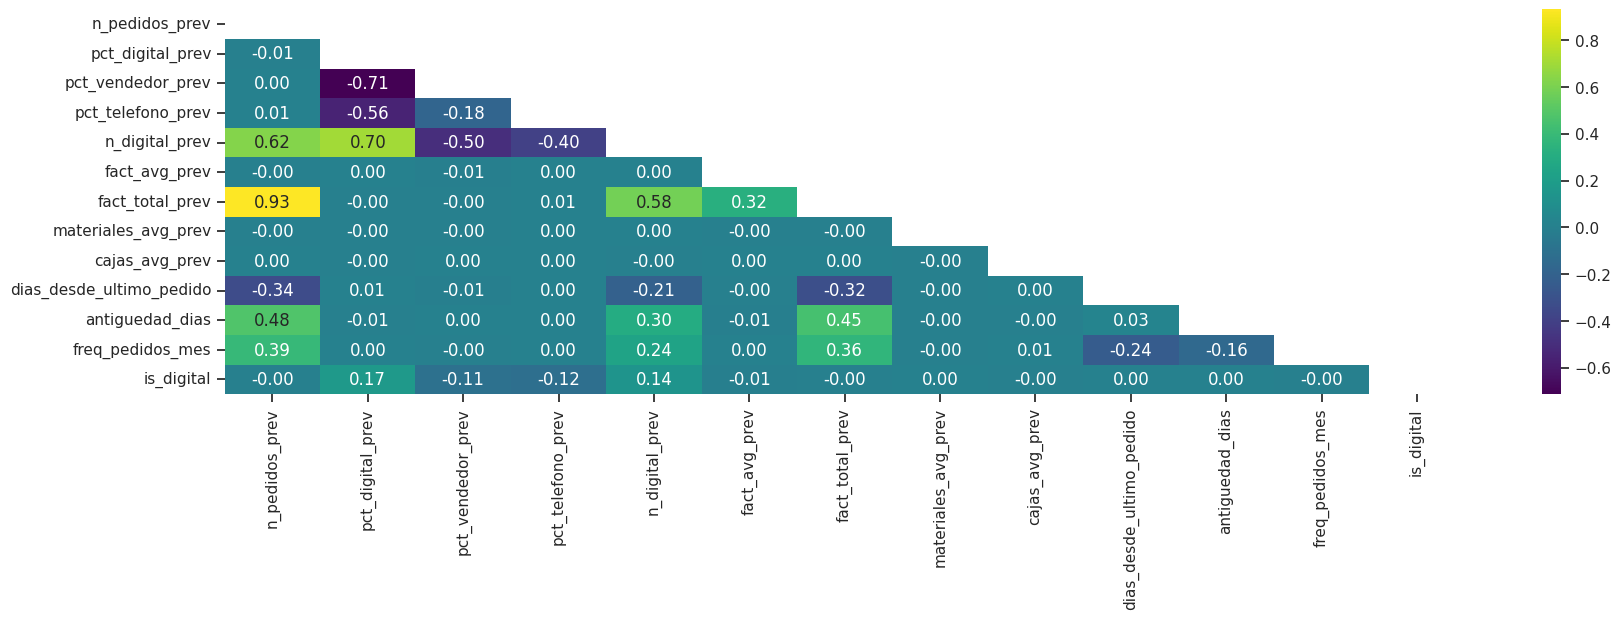

In [0]:
data_graf = train_df[num_cols + ["is_digital"]].corr()
mask = np.zeros_like(data_graf, dtype=np.bool_)
mask[np.tril_indices_from(mask)] = True

plt.figure(figsize=(20,5))
sns.heatmap(data_graf, mask=np.triu(np.ones_like(data_graf)), cmap=plt.cm.viridis, annot=True, fmt=".2f")
plt.show()

In [0]:
corr = train_df[num_cols + ["is_digital"]].corr()["is_digital"].drop("is_digital")
print(corr.sort_values(key=abs, ascending=False))

pct_digital_prev            0.172108
n_digital_prev              0.136283
pct_telefono_prev          -0.115908
pct_vendedor_prev          -0.105859
fact_avg_prev              -0.006424
fact_total_prev            -0.003689
freq_pedidos_mes           -0.002818
n_pedidos_prev             -0.002039
dias_desde_ultimo_pedido    0.001859
antiguedad_dias             0.001822
cajas_avg_prev             -0.001741
materiales_avg_prev         0.001591
Name: is_digital, dtype: float64


In [0]:
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(train_df[num_cols].fillna(0), train_df["is_digital"], random_state=0)
mi = pd.Series(mi, index=num_cols).sort_values(ascending=False)
print(mi)

pct_digital_prev            0.015283
n_digital_prev              0.010748
pct_telefono_prev           0.006875
pct_vendedor_prev           0.006105
fact_total_prev             0.001729
n_pedidos_prev              0.000326
fact_avg_prev               0.000000
materiales_avg_prev         0.000000
cajas_avg_prev              0.000000
dias_desde_ultimo_pedido    0.000000
antiguedad_dias             0.000000
freq_pedidos_mes            0.000000
dtype: float64


In [0]:
from sklearn.preprocessing import OrdinalEncoder

# Codificar categóricas a enteros (el orden no importa para MI)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_cat = enc.fit_transform(train_df[cat_cols].astype(str))

mi_cat = mutual_info_classif(
    X_cat,
    train_df["is_digital"],
    discrete_features=True,   # <-- clave: todas son discretas
    random_state=0,
)
mi_cat = pd.Series(mi_cat, index=cat_cols).sort_values(ascending=False)
print(mi_cat)

madurez_digital_cd       0.043000
estrellas_txt            0.005711
canal_pedido_prev        0.003478
ever_digital_prev        0.001287
region_comercial_txt     0.000031
frecuencia_visitas_cd    0.000016
pais_cd                  0.000007
tipo_cliente_cd          0.000007
dtype: float64


In [0]:
train_df["canal_pedido_prev"].value_counts()

canal_pedido_prev
DIGITAL     52164
VENDEDOR    36519
TELEFONO    19999
Name: count, dtype: int64

Eliminamos variables altamente correlacionadas para evitar la multicolinealidad

In [0]:
num_cols = [
    #"n_pedidos_prev",
    "pct_digital_prev",
    #"pct_vendedor_prev",
    "pct_telefono_prev",
    #"n_digital_prev",
    #"fact_avg_prev",
    #"fact_total_prev",
    #"materiales_avg_prev",
    #"cajas_avg_prev",
    "dias_desde_ultimo_pedido",
    #"antiguedad_dias",
    "freq_pedidos_mes",
]

calc_vif(train_df[num_cols]).display()

variables,VIF
pct_digital_prev,2.87698675931787
pct_telefono_prev,1.7774929318959536
dias_desde_ultimo_pedido,1.890169620935342
freq_pedidos_mes,2.82785856890796


Convertir variables categoricas mediante one hot enconding y las numericas con minmax scaler

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import pandas as pd

# --- Listas de features elegidas en feature selection ---
cat_features = [
    "madurez_digital_cd",
    "estrellas_txt",
    "canal_pedido_prev",
    "ever_digital_prev",
]
num_features = [
    "pct_digital_prev",
    "pct_telefono_prev",
    "dias_desde_ultimo_pedido",
    "freq_pedidos_mes",
]

# --- Preprocesador ---
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary",
                              sparse_output=False), cat_features),
        ("num", MinMaxScaler(), num_features),
    ],
    remainder="drop",
)

# --- Ajustar SOLO en train, transformar ambos ---
X_train = preprocessor.fit_transform(train_df)
X_test  = preprocessor.transform(test_df)

y_train = train_df["is_digital"].to_numpy()
y_test  = test_df["is_digital"].to_numpy()

# --- Reconstruir como DataFrame con nombres de columna (útil para importancias) ---
feat_names = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=feat_names, index=train_df.index)
X_test  = pd.DataFrame(X_test,  columns=feat_names, index=test_df.index)

# Modelos potenciales

In [0]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from skopt import BayesSearchCV
from skopt.space import Real, Integer
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

import warnings
warnings.filterwarnings("ignore")

In [0]:
def benchmark_binary_balanced(X_train, y_train, X_test, y_test,
                               cv_folds=5, random_state=1997):
    """
    Entrena y evalúa múltiples modelos sklearn para clasificación binaria BALANCEADA.

    Parámetros
    ----------
    X_train, y_train : datos de entrenamiento
    X_test,  y_test  : datos de evaluación
    cv_folds         : folds para cross-validation
    random_state     : semilla

    Retorna
    -------
    pd.DataFrame ordenado por F1 de clase 1 (descendente)
    """

    models = {
        "RandomForest": RandomForestClassifier(
            max_depth=5, n_estimators=500,
            min_samples_split=10, min_samples_leaf=1,
            random_state=random_state, n_jobs=-1
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=1000, solver="lbfgs",
            random_state=random_state
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            min_samples_leaf=10, random_state=random_state
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=15, weights="distance", n_jobs=-1
        ),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=5, min_samples_leaf=10, random_state=random_state
        ),
    }

    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=300, max_depth=4,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state, n_jobs=-1
        )

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    results = []

    for name, model in models.items():
        print(f"  Entrenando {name}...")

        # CV en train para estimar generalización
        cv_proba = cross_val_predict(model, X_train, y_train,
                                     cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
        cv_pred  = (cv_proba >= 0.5).astype(int)

        # Entrenamiento final y evaluación en test
        model.fit(X_train, y_train)
        test_proba = model.predict_proba(X_test)[:, 1]
        test_pred  = (test_proba >= 0.5).astype(int)

        results.append({
            "modelo":            name,
            # — métricas en TEST (lo que más importa) —
            "accuracy_test":     round(accuracy_score(y_test, test_pred),              4),
            "f1_1_test":         round(f1_score(y_test, test_pred, pos_label=1),       4),
            "precision_1_test":  round(precision_score(y_test, test_pred, pos_label=1),4),
            "recall_1_test":     round(recall_score(y_test, test_pred, pos_label=1),   4),
            "roc_auc_test":      round(roc_auc_score(y_test, test_proba),              4),
            "pr_auc_test":       round(average_precision_score(y_test, test_proba),    4),
            # — referencia de estabilidad (CV en train) —
            "accuracy_cv":       round(accuracy_score(y_train, cv_pred),               4),
            "f1_1_cv":           round(f1_score(y_train, cv_pred, pos_label=1),        4),
        })

    df = (
        pd.DataFrame(results)
        .sort_values("f1_1_test", ascending=False)
        .reset_index(drop=True)
    )
    df.index += 1  # ranking desde 1

    print("\n" + "="*70)
    print(f"  BENCHMARK (balanceado) — threshold=0.5 | cv_folds={cv_folds}")
    print("="*70)
    print(df.to_string())
    print("="*70)
    return df

In [0]:
summary = benchmark_binary_balanced(
    X_train, y_train,
    X_test,  y_test,
    cv_folds=5
)

  Entrenando RandomForest...
  Entrenando LogisticRegression...
  Entrenando GradientBoosting...
  Entrenando KNN...
  Entrenando DecisionTree...
  Entrenando XGBoost...

  BENCHMARK (balanceado) — threshold=0.5 | cv_folds=5
               modelo  accuracy_test  f1_1_test  precision_1_test  recall_1_test  roc_auc_test  pr_auc_test  accuracy_cv  f1_1_cv
1        DecisionTree         0.6263     0.6223            0.6074         0.6380        0.6504       0.6068       0.6297   0.6216
2        RandomForest         0.6276     0.6214            0.6099         0.6334        0.6484       0.6344       0.6300   0.6220
3  LogisticRegression         0.6276     0.6214            0.6099         0.6334        0.6502       0.6339       0.6300   0.6221
4    GradientBoosting         0.6271     0.6200            0.6101         0.6302        0.6491       0.6339       0.6290   0.6189
5             XGBoost         0.6271     0.6200            0.6100         0.6303        0.6505       0.6335       0.6294   0.

In [0]:

def tune_xgboost_bayesian(X_train, y_train,
                           n_iter=50,
                           cv_folds=5,
                           random_state=1997):
    """
    Optimización bayesiana de XGBoost con BayesSearchCV.
    Métrica objetivo: recall de la clase 1.
    """
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    search_space = {
        "n_estimators":       Integer(100, 600),
        "max_depth":          Integer(3,   6),
        "learning_rate":      Real(0.01, 0.3,  prior="log-uniform"),
        "subsample":          Real(0.5,  1.0),
        "colsample_bytree":   Real(0.4,  1.0),
        "colsample_bylevel":  Real(0.4,  1.0),
        "min_child_weight":   Real(1,    10),
        "gamma":              Real(0,    5),
        "reg_alpha":          Real(0,    10),
        "reg_lambda":         Real(0,    10),
        "scale_pos_weight":   Real(scale_pos_weight * 0.5,
                                   scale_pos_weight * 2.0),
    }

    base_model = XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=random_state,
        n_jobs=-1,
    )

    scorer = make_scorer(balanced_accuracy_score)
    cv     = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    opt = BayesSearchCV(
        estimator=base_model,
        search_spaces=search_space,
        scoring=scorer,
        cv=cv,
        n_iter=n_iter,
        n_points=1,          
        n_jobs=-1,
        refit=True,           
        random_state=random_state,
        verbose=0,
    )

    print(f"\nIniciando BayesSearchCV: {n_iter} iteraciones, {cv_folds}-fold CV")
    print("="*60)
    
    ## Optimizar
    opt.fit(X_train, y_train)

    print("\n" + "="*60)
    print(f"  Mejor recall_1 CV : {opt.best_score_:.4f}")
    print(f"  Mejores parámetros:")
    for k, v in opt.best_params_.items():
        print(f"    {k:<22} = {v}")
    print("="*60)

    results_df = (
        pd.DataFrame(opt.cv_results_)
        .sort_values("mean_test_score", ascending=False)
        .reset_index(drop=True)
        [["mean_test_score", "std_test_score", "params"]]
    )
    results_df.index += 1

    return opt.best_estimator_, opt.best_params_, results_df

In [0]:
from sklearn.metrics import make_scorer

best_model, best_params, history_df = tune_xgboost_bayesian(
    X_train, y_train,
            n_iter=50,
            cv_folds=5,
            random_state=1997
)

# Evaluar en test
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)
print(classification_report(y_test, pred_test))


Iniciando BayesSearchCV: 50 iteraciones, 5-fold CV

Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


  Mejor recall_1 CV : 0.6303
  Mejores parámetros:
    colsample_bylevel      = 0.4
    colsample_bytree       = 0.4
    gamma                  = 3.5873054943811002
    learning_rate          = 0.29999999999999993
    max_depth              = 3
    min_child_weight       = 1.0
    n_estimators           = 600
    reg_alpha              = 7.710007020315414
    reg_lambda             = 0.0
    scale_pos_weight       = 0.9473539981267164
    subsample              = 0.6424765065021945
              precision    recall  f1-score   support

           0       0.65      0.62      0.63     21200
           1       0.61      0.63      0.62     19773

    accuracy                           0.63     40973
   macro avg       0.63      0.63      0.63     40973
weighted avg       0.63      0.63      0.63     40973



In [0]:
model_xg = XGBClassifier(
    colsample_bylevel      = 0.4,
    colsample_bytree       = 0.4,
    gamma                  = 3.5873054943811002,
    learning_rate          = 0.29999999999999993,
    max_depth              = 3,
    min_child_weight       = 1.0,
    n_estimators           = 600,
    reg_alpha              = 7.710007020315414,
    reg_lambda             = 0.0,
    scale_pos_weight       = 0.9473539981267164,
    subsample              = 0.6424765065021945,
    eval_metric="logloss",
    tree_method="hist",
    random_state=1997,
    n_jobs=-1,
)

In [0]:
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.4, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None,
              gamma=3.5873054943811002, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.29999999999999993,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1.0, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [0]:
y_pred_train = model_xg.predict_proba(X_train)[:, 1]
y_pred_test = model_xg.predict_proba(X_test)[:, 1]

In [0]:
df_train = adjusted_prediction(y_train, y_pred_train, 0.5, 0.5)
model_metrics(df_train)

Accuracy: 0.6300123295485913
Balanced Accuracy: 0.6301641382804857
ks: 0.25985206887597434
ROC AUC: 0.6573069250107293
Gini: 0.3146138500214586
Negative Predicted value:  0.6103124365622751
Positive Predicted value:  0.6496008808147536
Sensitivity:  0.626371293085144
Specificity:  0.6339569834758272
tp, fn, fp, tn=:  [np.int64(35400), np.int64(21116), np.int64(19095), np.int64(33071)]
Confusion Matrix:
[[35400 21116]
 [19095 33071]]
              precision    recall  f1-score   support

           0       0.65      0.63      0.64     56516
           1       0.61      0.63      0.62     52166

    accuracy                           0.63    108682
   macro avg       0.63      0.63      0.63    108682
weighted avg       0.63      0.63      0.63    108682



In [0]:
df_test = adjusted_prediction(y_test, y_pred_test, 0.5, 0.5)
model_metrics(df_test)

Accuracy: 0.6277548629585337
Balanced Accuracy: 0.6279427802730806
ks: 0.2555748190070508
ROC AUC: 0.6488031528127264
Gini: 0.29760630562545276
Negative Predicted value:  0.6101339829476249
Positive Predicted value:  0.645442097026604
Sensitivity:  0.6225471698113207
Specificity:  0.6333383907348404
tp, fn, fp, tn=:  [np.int64(13198), np.int64(8002), np.int64(7250), np.int64(12523)]
Confusion Matrix:
[[13198  8002]
 [ 7250 12523]]
              precision    recall  f1-score   support

           0       0.65      0.62      0.63     21200
           1       0.61      0.63      0.62     19773

    accuracy                           0.63     40973
   macro avg       0.63      0.63      0.63     40973
weighted avg       0.63      0.63      0.63     40973



In [0]:
12523/(12523+7250)

0.6333383907348404

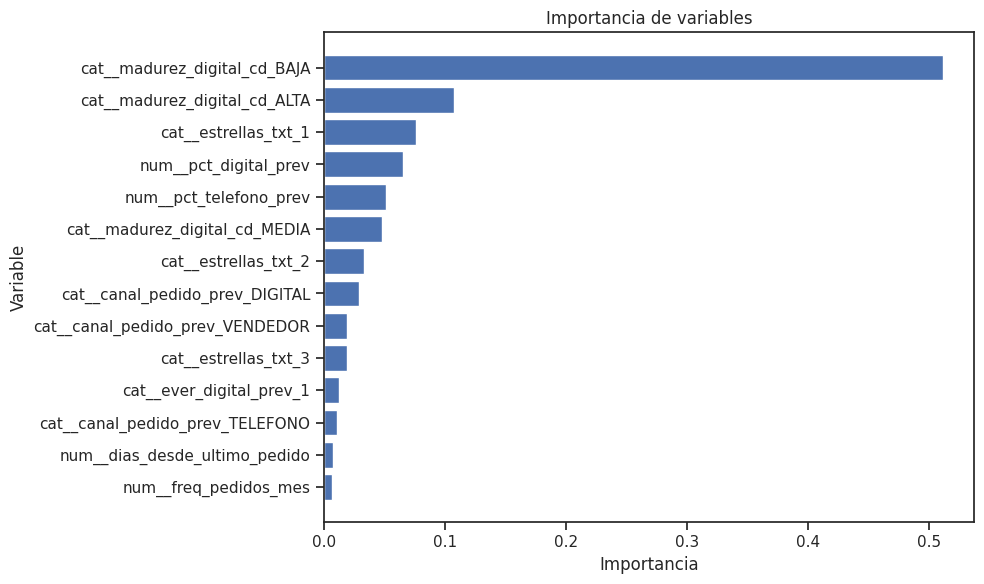

In [0]:
importances = model_xg.feature_importances_

booster_names = model_xg.get_booster().feature_names
if booster_names is not None:
    var = booster_names
else:
    var = [f"f{i}" for i in range(len(importances))]

feat_importances = (
    pd.DataFrame({"variable": var, "importance": importances})
    .sort_values(by="importance", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(feat_importances["variable"], feat_importances["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables")
plt.tight_layout()
plt.show()

In [0]:
import mlflow
import os
import shutil
from joblib import dump, load
from sklearn.pipeline import Pipeline

def register_model(model, scaler, X_train, schema, metrics,
                   model_path, model_name):
    
    # Crear pipeline (scaler -> modelo)
    pipeline = Pipeline([
    ("scaler", scaler),
    ("model", model)
    ])

    # Limpiar carpeta destino por consistencia 
    if os.path.exists(model_path):
        shutil.rmtree(model_path)
    os.makedirs(model_path, exist_ok=True)

    # Guardar el modelo en el path especificado
    dump(pipeline, model_path+f"/{model_name}.joblib")

    # Firmar el modelo 
    full_model_name = f"{schema}.{model_name}"

    with mlflow.start_run():
        # Registrar métricas
        for key, value in metrics.items():
            mlflow.log_metric(key, value)
        # Registrar solo el modelo
        mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path="model",
            input_example=X_train,
            registered_model_name=full_model_name
        )

In [0]:
def calcular_metricas_mlflow(data,corte_optimo):
    """
    Calcula métricas del modelo y devuelve un diccionario listo para registrar en MLflow.
    Se espera que `data` tenga las columnas:
        - 'Adjusted Prediction'
        - 'Probability'
        - 'True Dependent Variable'
    """
    y_pred = data['Adjusted Prediction']
    y_prob = data['Probability']
    y_true = data['True Dependent Variable']

    # Métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    ks = ks_metric(data, 'Probability', 'True Dependent Variable')  # Tu función KS

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Clase 0 (negativa)
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_0 = (2 * precision_0 * recall_0) / (precision_0 + recall_0) if (precision_0 + recall_0) > 0 else 0

    # Clase 1 (positiva)
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_1 = (2 * precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

    # Balanced accuracy, sensibilidad, especificidad
    sensibilidad = recall_1
    especificidad = recall_0

    return {
        "corte_optimo": corte_optimo,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "roc_auc": auc,
        "gini": gini,
        "ks": ks,
        "recall_0": recall_0,
        "recall_1": recall_1,
        "precision_0": precision_0,
        "precision_1": precision_1,
        "f1_score_0": f1_0,
        "f1_score_1": f1_1,
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

In [0]:
probability_test = y_pred_test
df_test = adjusted_prediction(y_test, y_pred_test, 0.5, 0.5)
metricas_toSave = calcular_metricas_mlflow(df_test,0.5)
print(metricas_toSave)

{'corte_optimo': 0.5, 'accuracy': 0.6277548629585337, 'balanced_accuracy': np.float64(0.6279427802730806), 'roc_auc': np.float64(0.6488031528127264), 'gini': np.float64(0.29760630562545276), 'ks': 0.2555748190070508, 'recall_0': np.float64(0.6225471698113207), 'recall_1': np.float64(0.6333383907348404), 'precision_0': np.float64(0.645442097026604), 'precision_1': np.float64(0.6101339829476249), 'f1_score_0': np.float64(0.6337879369957742), 'f1_score_1': np.float64(0.6215196783959502), 'sensibilidad': np.float64(0.6333383907348404), 'especificidad': np.float64(0.6225471698113207), 'tp': np.int64(12523), 'tn': np.int64(13198), 'fp': np.int64(8002), 'fn': np.int64(7250)}


Finalmente registramos el modelo con MLFLOW

In [0]:
register_model(
    model=model_xg, 
    scaler=preprocessor, 
    X_train=X_train, 
    schema="default", 
    metrics=metricas_toSave,
    model_path="/Volumes/workspace/default/model_cliente_digital_01", 
    model_name="model_cliente_digital_01"
) 